**APPLICATION DEVELOPMENT CLASS NOTES**

> 255041 알레    /   교수: 조상구







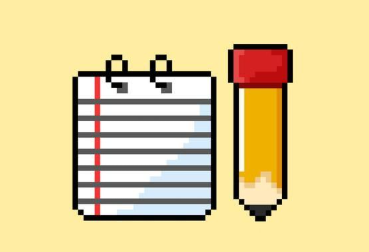

**1.REQUESTS**

> (requests 모듈)
> > 서버에 데이터를 요청하거나 보낼 때 사용하는 파이썬 라이브러리입니다.



**2.웹 CRUD**

> 데이터의 4가지 기본 기능인 생성, 조회, 수정, 삭제를 의미합니다.



In [1]:
import requests

# 1. GET: (제품 목록 조회)
res = requests.get("https://fakestoreapi.com/products")

# 2. GET: (특정 제품 조회)
res = requests.get("https://fakestoreapi.com/products/1")

# 3. POST: (새 제품 생성)
new_item = {"title": "Shoes", "price": 50}
res = requests.post("https://fakestoreapi.com/products", json=new_item)

# 4. PUT: (제품 수정)
res = requests.put("https://fakestoreapi.com/products/1", json={"price": 60})

# 5. DELETE:(제품 삭제)
res = requests.delete("https://fakestoreapi.com/products/1")

**3. JSON & Python Dictionary**


> JSON은 데이터를 저장하고 전송할 때 사용하는 텍스트 형식이며, 파이썬의 Dictionary와 구조가 같습니다.



In [3]:
user_dict = {"name": "Alice", "age": 25}

user_json = '{"name": "Alice", "age": 25}'

In [4]:
import json
data = {"id": 1, "task": "Study"}

# Serialization: Dict -> String (직렬화)
json_string = json.dumps(data)
print(json_string) # Result: '{"id": 1, "task": "Study"}'

{"id": 1, "task": "Study"}


In [5]:
import requests

my_dict = {"title": "Hello"}

# 'json=' 옵션을 쓰면 파이썬이 알아서 JSON으로 변환해줍니다!
response = requests.post("https://httpbin.org/post", json=my_dict)

**예:**

In [7]:
import requests
import json
import pandas as pd

print("--- 1. CRUD Examples ---")

read_res = requests.get("https://fakestoreapi.com/products/1")
print(f"GET (Read) Status: {read_res.status_code}")
print(f"Data Received: {read_res.json()['title']}\n")

new_item = {"title": "Student Shoes", "price": 45.0, "category": "clothing"}
create_res = requests.post("https://fakestoreapi.com/products", json=new_item)
print(f"POST (Create) Status: {create_res.status_code}")
print(f"Server Response: {create_res.json()}\n")


print("--- 2. JSON & Serialization ---")
student_dict = {"name": "User", "assignment": "Task_02", "status": "Finished"}

json_string = json.dumps(student_dict)

print(f"Python Dictionary Type: {type(student_dict)}")
print(f"JSON String Type: {type(json_string)}")
print(f"Serialized String for Transmission: {json_string}\n")


print("--- 3. Automatic Conversion ---")

response = requests.post("https://httpbin.org/post", json=student_dict)

server_received = response.json()['data']
print(f"The server received this string: {server_received}")
print("Proof: The server received a STRING, even though we sent a DICT.")

--- 1. CRUD Examples ---
GET (Read) Status: 200
Data Received: Fjallraven - Foldsack No. 1 Backpack, Fits 15 Laptops

POST (Create) Status: 201
Server Response: {'id': 21, 'title': 'Student Shoes', 'price': 45, 'category': 'clothing'}

--- 2. JSON & Serialization ---
Python Dictionary Type: <class 'dict'>
JSON String Type: <class 'str'>
Serialized String for Transmission: {"name": "User", "assignment": "Task_02", "status": "Finished"}

--- 3. Automatic Conversion ---
The server received this string: {"name": "User", "assignment": "Task_02", "status": "Finished"}
Proof: The server received a STRING, even though we sent a DICT.


**4.서버 헤더 정보 비교**



> 웹 페이지를 요청할 때 서버는 헤더 정보를 함께 보냅니다. 이는 서버 소프트웨어 종류, 데이터 형식, 보안 정책 등 서버에 대한 메타데이터를 담고 있습니다.




In [8]:
import requests

# 네이버와 구글 URL 정의
naver_url = "https://www.naver.com"
google_url = "https://www.google.com"

# 요청 보내기
naver_res = requests.get(naver_url)
google_res = requests.get(google_url)

# 헤더 정보 출력 및 비교
print("=== [NAVER] Server Headers ===")

#구글은 보통 gws(Google Web Server)라고 표시되지만
#네이버는 보안을 위해 이름을 숨기거나 다른 이름을 사용합니다.

print(f"Server Software: {naver_res.headers.get('Server')}")
print(f"Content Type: {naver_res.headers.get('Content-Type')}")

print("\n=== [GOOGLE] Server Headers ===")

print(f"Server Software: {google_res.headers.get('Server')}")
print(f"Content Type: {google_res.headers.get('Content-Type')}")

# 전체 헤더 확인용
# print(dict(naver_res.headers))

=== [NAVER] Server Headers ===
Server Software: nfront
Content Type: text/html; charset=UTF-8

=== [GOOGLE] Server Headers ===
Server Software: gws
Content Type: text/html; charset=ISO-8859-1


In [10]:
import requests

def print_headers(url, name):
    response = requests.get(url)
    print(f"\n{'='*20} [{name}] 전체 헤더 {'='*20}")
    # 헤더 딕셔너리를 보기 좋게 출력
    for key, value in response.headers.items():
        print(f"{key}: {value}")

# 네이버와 구글 전체 헤더 출력
print_headers("https://www.naver.com", "NAVER")
print_headers("https://www.google.com", "GOOGLE")


==================== [NAVER] 전체 헤더 ====================
Content-Type: text/html; charset=UTF-8
Cache-Control: no-cache, no-store, must-revalidate
Pragma: no-cache
x-frame-options: DENY
x-xss-protection: 1; mode=block
strict-transport-security: max-age=63072000; includeSubdomains
referrer-policy: unsafe-url
Content-Encoding: gzip
Server: nfront
Content-Length: 32487
Date: Fri, 27 Mar 2026 04:13:41 GMT
Connection: keep-alive
Vary: Accept-Encoding

==================== [GOOGLE] 전체 헤더 ====================
Date: Fri, 27 Mar 2026 04:13:41 GMT
Expires: -1
Cache-Control: private, max-age=0
Content-Type: text/html; charset=ISO-8859-1
Content-Security-Policy-Report-Only: object-src 'none';base-uri 'self';script-src 'nonce-_L_XolKhIiXSLEe81M4QYw' 'strict-dynamic' 'report-sample' 'unsafe-eval' 'unsafe-inline' https: http:;report-uri https://csp.withgoogle.com/csp/gws/other-hp
Reporting-Endpoints: default="//www.google.com/httpservice/retry/jserror?ei=9QPGaYeqEK2P9u8Pxejq-QI&cad=crash&error=Page%2

**5. JSON 데이터를 데이터프레임으로 변환 및 중첩 구조 펼치기**

> *데이터프레임 변환:* API에서 가져온 JSON(딕셔너리 리스트)을 판다스의 DataFrame으로 바꾸면 엑셀 표처럼 관리할 수 있습니다.

> *중첩 해제:* address처럼 컬럼 안에 또 다른 데이터 구조가 들어있을 때, 이를 개별 컬럼으로 나누는 것을 '평탄화'라고 합니다.





In [11]:
import requests
import pandas as pd

# 1. API 주소 설정 및 데이터 불러오기
url = "https://jsonplaceholder.typicode.com/users"
response = requests.get(url)
data = response.json()  # JSON 데이터를 파이썬 리스트/딕셔너리로 변환

# 2. 전체 데이터를 데이터프레임으로 저장
df = pd.DataFrame(data)
print("--- [Step 1] 전체 데이터프레임 (address 컬럼 확인) ---")
display(df[['name', 'email', 'address']].head(3))
# 여기서 address 컬럼을 보면 {street: ..., city: ...} 처럼 뭉쳐 보입니다.

# 3. "address" 컬럼(Series)의 내용만 따로 데이터프레임으로 변환
# pd.json_normalize는 딕셔너리 형태의 데이터를 표 형태로 펼쳐줍니다.
address_df = pd.json_normalize(df['address'])

print("\n--- [Step 2] 'address' 컬럼만 분리하여 만든 데이터프레임 ---")
display(address_df.head(5))

--- [Step 1] 전체 데이터프레임 (address 컬럼 확인) ---


,name,email,address
0,Leanne Graham,Sincere@april.biz,"{'street': 'Kulas Light', 'suite': 'Apt. 556',..."
1,Ervin Howell,Shanna@melissa.tv,"{'street': 'Victor Plains', 'suite': 'Suite 87..."
2,Clementine Bauch,Nathan@yesenia.net,"{'street': 'Douglas Extension', 'suite': 'Suit..."



--- [Step 2] 'address' 컬럼만 분리하여 만든 데이터프레임 ---


,street,suite,city,zipcode,geo.lat,geo.lng
0,Kulas Light,Apt. 556,Gwenborough,92998-3874,-37.3159,81.1496
1,Victor Plains,Suite 879,Wisokyburgh,90566-7771,-43.9509,-34.4618
2,Douglas Extension,Suite 847,McKenziehaven,59590-4157,-68.6102,-47.0653
3,Hoeger Mall,Apt. 692,South Elvis,53919-4257,29.4572,-164.2990
4,Skiles Walks,Suite 351,Roscoeview,33263,-31.8129,62.5342


**6.짝수 인덱스 데이터 추출 및 엑셀 저장**

> *필터링:* df.index % 2 == 0 조건을 사용하여 인덱스 번호를 2로 나눈 나머지가 0인 행(짝수 행: 0, 2, 4...)만 골라냅니다.

> *내보내기:* 판다스의 to_excel() 함수를 사용하면 데이터프레임을 아주 쉽게 엑셀 파일(.xlsx)로 바꿀 수 있습니다.


> *다운로드:* 코랩 환경에서는 생성된 파일을 내 컴퓨터로 가져오기 위해 google.colab의 files 기능을 사용해야 합니다.







In [12]:
import requests
import pandas as pd
from google.colab import files # For downloading the file (파일 다운로드용)

#데이터 가져오기
url = "https://jsonplaceholder.typicode.com/posts"
response = requests.get(url)
df = pd.DataFrame(response.json())

# 인덱스가 짝수인 데이터만 필터링
# % 나머지 연산자
even_df = df[df.index % 2 == 0]


print("--- [한국어] 짝수 인덱스 행 미리보기: ---")
display(even_df.head(5))

# 엑셀 파일로 저장
file_name = "even_posts.xlsx"
even_df.to_excel(file_name, index=False)

#내 컴퓨터로 다운로드
print(f"\nDownloading {file_name}...")
files.download(file_name)

--- [한국어] 짝수 인덱스 행 미리보기: ---


,userId,id,title,body
0,1,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...
2,1,3,ea molestias quasi exercitationem repellat qui...,et iusto sed quo iure\nvoluptatem occaecati om...
4,1,5,nesciunt quas odio,repudiandae veniam quaerat sunt sed\nalias aut...
6,1,7,magnam facilis autem,dolore placeat quibusdam ea quo vitae\nmagni q...
8,1,9,nesciunt iure omnis dolorem tempora et accusan...,consectetur animi nesciunt iure dolore\nenim q...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
import requests
import pandas as pd
from google.colab import files

url = "https://jsonplaceholder.typicode.com/posts"
response = requests.get(url)
df = pd.DataFrame(response.json())


even_df = df[df.index % 2 == 0].copy()

# 컬럼명을 한글로 변경
# Mapping: {'Old Name': 'New Name'}
korean_columns = {
    'userId': '사용자ID',
    'id': '글번호',
    'title': '제목',
    'body': '내용'
}
even_df = even_df.rename(columns=korean_columns)

print("--- [English] Table with Korean Headers: ---")
print("--- [한국어] 한글로 변경된 테이블 정보: ---")
display(even_df.head(5))

#저장 및 다운로드
file_name = "even_posts_korean.xlsx"
even_df.to_excel(file_name, index=False)
files.download(file_name)

--- [English] Table with Korean Headers: ---
--- [한국어] 한글로 변경된 테이블 정보: ---


,사용자ID,글번호,제목,내용
0,1,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...
2,1,3,ea molestias quasi exercitationem repellat qui...,et iusto sed quo iure\nvoluptatem occaecati om...
4,1,5,nesciunt quas odio,repudiandae veniam quaerat sunt sed\nalias aut...
6,1,7,magnam facilis autem,dolore placeat quibusdam ea quo vitae\nmagni q...
8,1,9,nesciunt iure omnis dolorem tempora et accusan...,consectetur animi nesciunt iure dolore\nenim q...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**7. Gradio를 통한 실시간 데이터 필터링**
> *목표:* 사용자가 userId를 입력하면 해당 사용자의 포스트만 실시간으로 업데이트하여 보여주는 검색창(UI)을 만듭니다.

> *동적 요청:* 모든 데이터를 가져오는 대신 params={'userId': 입력값}을 사용합니다. 이는 서버에게 "이 ID에 해당하는 데이터만 보내줘"라고 요청하는 방식입니다.

> *Gradio 인터페이스:* 입력창과 출력창(데이터프레임)을 정의하여 웹 화면을 구성합니다.

In [14]:
import requests
import pandas as pd
import gradio as gr

def get_user_posts(user_id):
    url = "https://jsonplaceholder.typicode.com/posts"


    # 서버에 보낼 파라미터 설정 (특정 userId만 요청)
    params = {'userId': user_id}

    response = requests.get(url, params=params)

    if response.status_code == 200:
        df = pd.DataFrame(response.json())


        # 컬럼명을 한글로 변경 (선택사항이지만 더 보기 좋습니다)
        korean_columns = {'userId': '사용자ID', 'id': '글번호', 'title': '제목', 'body': '내용'}
        df = df.rename(columns=korean_columns)

        return df
    else:
        return pd.DataFrame(["Error fetching data"], columns=["Error"])

# Gradio 인터페이스 생성
demo = gr.Interface(
    fn=get_user_posts,           # 실행할 함수
    inputs=gr.Number(label="Enter User ID (1-10)"), # 입력: 숫자
    outputs="dataframe",         # 출력: 데이터프레임
    title="User Post Finder",    #제목
    description="Type a User ID to see their specific posts from the API."
)


demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://aa4507b9415398cdee.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [15]:
#KOREAN VERSION
import requests
import pandas as pd
import gradio as gr

def get_korean_posts(user_id):
    url = "https://jsonplaceholder.typicode.com/posts"
    params = {'userId': user_id}
    response = requests.get(url, params=params)

    if response.status_code == 200:
        df = pd.DataFrame(response.json())

        korean_columns = {
            'userId': '사용자_번호',
            'id': '게시글_ID',
            'title': '글_제목',
            'body': '본문_내용'
        }
        df = df.rename(columns=korean_columns)


        df['본문_내용'] = "내용: " + df['본문_내용']

        return df
    else:
        return pd.DataFrame(["데이터를 가져오는데 실패했습니다."], columns=["에러"])

demo = gr.Interface(
    fn=get_korean_posts,
    inputs=gr.Number(label="사용자 ID를 입력하세요 (1-10)"),
    outputs=gr.Dataframe(label="필터링된 결과"),
    title="사용자별 포스트 조회기",
    description="입력한 ID에 해당하는 사용자의 글을 실시간으로 가져옵니다."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://862ec3039c41f7179f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
